# Assignment 1. Exploratory Modeling with JUSTICE

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE v0.1.4
**Contact:** J.ZatarainSalazar@tudelft.nl  


## Learning Outcomes

After completing this assignment you will be able to:
1. Verify that the JUSTICE model is installed and runs correctly.
2. Identify and define **model input uncertainties**.
3. Use **Latin Hypercube Sampling** to generate a scenario ensemble that spans the uncertainty space.
4. Run JUSTICE across many scenarios under different policy assumptions and collect the outcomes.
5. Visualise outcome **distributions**, **pair plots**, and **time series envelopes** to characterise how uncertainty propagates.


---

## Background

When building models of complex systems (climate, economy, ecology) we rarely know
the exact value of every parameter. A damage-function coefficient, a discount rate,
or a climate sensitivity parameter are all uncertain. **Exploratory modeling** treats
uncertainty explicitly: we run *many* scenarios, sampling the uncertain parameters
systematically, and study the resulting spread in model outputs.

In this assignment we treat four parameters as uncertain:

| Symbol | Parameter | Default | Range | Description |
|--------|-----------|---------|-------|-------------|
| `ρ` | Pure rate of social time preference | 0.015 | [0.001, 0.030] | Contested in the Stern–Nordhaus debate |
| `η` | Elasticity of marginal utility | 1.45 | [0.5, 1.5] | Empirical estimates range widely |
| `δ` | Damage function scale factor | 1.0 | [0.5, 2.0] | Structural uncertainty in damage estimates |
| `ecs_ensemble` | FaIR ensemble member index | 1 | [1, 1001] | Selects a calibrated ECS parameter set |

`ecs_ensemble` is a *physical* uncertainty (how sensitive the climate system is to CO₂),
while `ρ`, `η`, and `δ` are *normative* uncertainties (contested values in economic ethics).

We also compare two **policies** that differ in their emission control rate:

| Policy | `ecr_plateau` | Description |
|--------|--------------|-------------|
| `no_abatement` | 0.0 | Zero mitigation effort throughout the simulation |
| `moderate_abatement` | 0.4 | 40 % emission reduction applied from the start |

---

## Step 0 — Verify your installation

Run the cell below. Every line should end with ✓.  
If any line shows ✗, follow the installation instructions in setup_and_orientation.html

In [1]:
import importlib, sys
required = ["justice", "numpy", "pandas", "matplotlib",
            "ema_workbench", "scipy", "seaborn"]
for pkg in required:
    found = importlib.util.find_spec(pkg) is not None
    print(f"  {'✓' if found else '✗'}  {pkg}")
print(f"\nPython {sys.version.split()[0]}")

  ✓  justice
  ✓  numpy
  ✓  pandas
  ✓  matplotlib
  ✓  ema_workbench
  ✓  scipy
  ✓  seaborn

Python 3.14.2


## Setup — Imports and model configuration

The cell below imports all required packages and applies a Python 3.14 compatibility patch for `matplotlib.path.Path.__deepcopy__`. It also configures EMA Workbench logging and defines the shared name lists for outcomes, parameters, and policies that are referenced throughout the notebook.

## Step 1 — Run JUSTICE with default parameters

Before exploring uncertainty, confirm the model runs with its default settings.

**Task 1.1** — Complete the `justice_model` function below. It should:
1. Hard-reset JUSTICE and instantiate a fresh model with the given `ecs_ensemble` index.
2. Set `rho` on `model.welfare_function.pure_rate_of_social_time_preference`.
3. Set `eta` on `model.welfare_function.elasticity_of_marginal_utility_of_consumption`.
4. Scale the three active damage coefficients (`coefficient_a`, `coefficient_b`, `damage_gdp_ratio_with_gradient`) by `delta`.
5. Run with zero abatement (`ECR = 0`) and return all four outcomes as a dict.

> **Note:** Default argument values are required by the EMA Workbench function model interface.

**Task 1.2** — Run the default case (`ecs_ensemble=1`, all other parameters at their defaults) and record the four outcome values.

In [2]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import logging
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging, Sample,
    SequentialEvaluator, MultiprocessingEvaluator,
)
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)   # suppress per-run INFO noise

OBJECTIVES   = ["welfare", "years_above_temperature_threshold",
                "welfare_loss_damage", "welfare_loss_abatement"]
PARAMS       = ["rho", "eta", "delta", "ecs_ensemble"]
POLICY_NAMES = ["no_abatement", "moderate_abatement"]

print("Imports OK")
import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

Imports OK


In [3]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    """EMA Workbench function model — configurable abatement, Utilitarian welfare.

    Parameters
    ----------
    ecr_plateau : float
        Emission control rate applied uniformly across all regions and timesteps.
        0.0 = no abatement; 0.4 = 40% abatement (moderate policy).
    """
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets["welfare"])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets["global_temperature"], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)

    # Global mean temperature trajectory (shape: n_timesteps)
    temp = np.squeeze(datasets["global_temperature"])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)
    temperature_trajectory = temp.astype(float)

    return {
        "welfare":                          welfare,
        "years_above_temperature_threshold": yat,
        "welfare_loss_damage":              float(np.abs(np.squeeze(wl_dmg))),
        "welfare_loss_abatement":           float(np.abs(np.squeeze(wl_abt))),
        "temperature_trajectory":           temperature_trajectory,
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]")
    else:
        print(f"  {k}: {v:.4f}")


  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


## Step 2 — Define uncertain parameters

**Task 2.1** — Complete the cell below by:
1. Creating a `Model` object wrapping `justice_model`.
2. Assigning `uncertainties` — four `RealParameter` objects matching the table in the Background.
3. Assigning `outcomes` — four `ScalarOutcome` objects.

**Task 2.2** — Explain in 2–3 sentences why a *higher* pure rate of time preference `ρ` tends to lead to *less* stringent near-term mitigation. Reference the Ramsey rule in your answer.

*(Write your answer here)*

**Task 2.3** — Explain why `ecs_ensemble` is a *physical* uncertainty while `ρ`, `η`, `δ` are *normative* uncertainties. What does this distinction imply about which outcomes each type of uncertainty can influence?

*(Write your answer here)*

In [4]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001,    0.030),
    RealParameter('eta',          0.5,      1.5),
    RealParameter('delta',        0.5,      2.0),
    RealParameter('ecs_ensemble', 1,     1001),
]

# Policy lever: emission control rate applied uniformly across all timesteps
em_model.levers = [
    RealParameter('ecr_plateau', 0.0, 1.0),
]

em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
    ArrayOutcome('temperature_trajectory'),
]

print(f"Uncertainties : {[u.name for u in em_model.uncertainties]}")
print(f"Levers        : {[l.name for l in em_model.levers]}")
print(f"Outcomes      : {[o.name for o in em_model.outcomes]}")


Uncertainties : ['rho', 'eta', 'delta', 'ecs_ensemble']
Levers        : ['ecr_plateau']
Outcomes      : ['welfare', 'years_above_temperature_threshold', 'welfare_loss_damage', 'welfare_loss_abatement', 'temperature_trajectory']


## Step 3 — Latin Hypercube Sampling ensemble

**Latin Hypercube Sampling (LHS)** divides each uncertain dimension into equally
probable intervals and samples exactly once from each interval. Compared to Monte Carlo,
it guarantees better coverage of the full parameter space with fewer samples.

`perform_experiments` uses LHS by default. A single call handles sampling, execution, and result collection.

**Task 3.1** — Run 100 scenarios using `SequentialEvaluator`. Store the results as:
- `experiments` — a DataFrame with one row per scenario and one column per parameter
- `outcomes` — a dict mapping outcome names to arrays

In [5]:
policies = [
    Sample('no_abatement',       ecr_plateau=0.0),
    Sample('moderate_abatement', ecr_plateau=0.4),
]

# Python 3.14 + tqdm ≥ 4.67 compatibility fix: in Jupyter, tqdm.tqdm is replaced
# by tqdm.notebook.tqdm, whose __init__ calls super().__init__() into std_tqdm.__init__
# which is wrapped with @envwrap(is_method=True) → partialmethod.  Python 3.14
# changed descriptor binding rules for partialmethod, causing infinite recursion.
# Forcing tqdm.tqdm back to the plain std variant avoids the notebook code path.
import tqdm as _tqdm_mod
if _tqdm_mod.tqdm is not _tqdm_mod.std.tqdm:
    _tqdm_mod.tqdm = _tqdm_mod.std.tqdm

# Note: MultiprocessingEvaluator gives large speed-ups for 500+ scenarios when
# run from a script (python run_experiments.py). Inside a Jupyter notebook the
# spawned worker processes cannot reliably re-import the venv, so we use
# SequentialEvaluator here. For script-based runs, swap the context manager.
with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(scenarios=100, policies=policies)

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_params  = experiments[PARAMS]
df_results['policy'] = experiments['policy'].values

print(f"Ensemble complete: {len(experiments)} runs  "
      f"({df_results['policy'].value_counts().to_dict()})")
print(df_results[OBJECTIVES].agg(['min', 'median', 'max']).round(2).to_string())

100%|████████████████████████████████████████| 200/200 [03:28<00:00,  1.04s/it]

Ensemble complete: 200 runs  ({'moderate_abatement': 100, 'no_abatement': 100})
         welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
min        67.47                              167.0                28.14                    2.17
median    415.52                              240.0               835.60                  529.78
max     33772.46                              268.0             34315.23               374188.02


## Step 4 — Visualise outcome distributions

**Task 4.1** — Plot a 2×2 grid of histograms showing the distribution of each
outcome across the 100 scenarios. Mark the **default run value** from Step 1
as a vertical dashed line on each panel.

**Task 4.2** — Plot a scatter matrix (pairplot) of the four uncertain parameters
coloured by `welfare` quartile. Use the `experiments` DataFrame to extract parameter columns.

*Hint: use `seaborn.pairplot` with `hue`.*

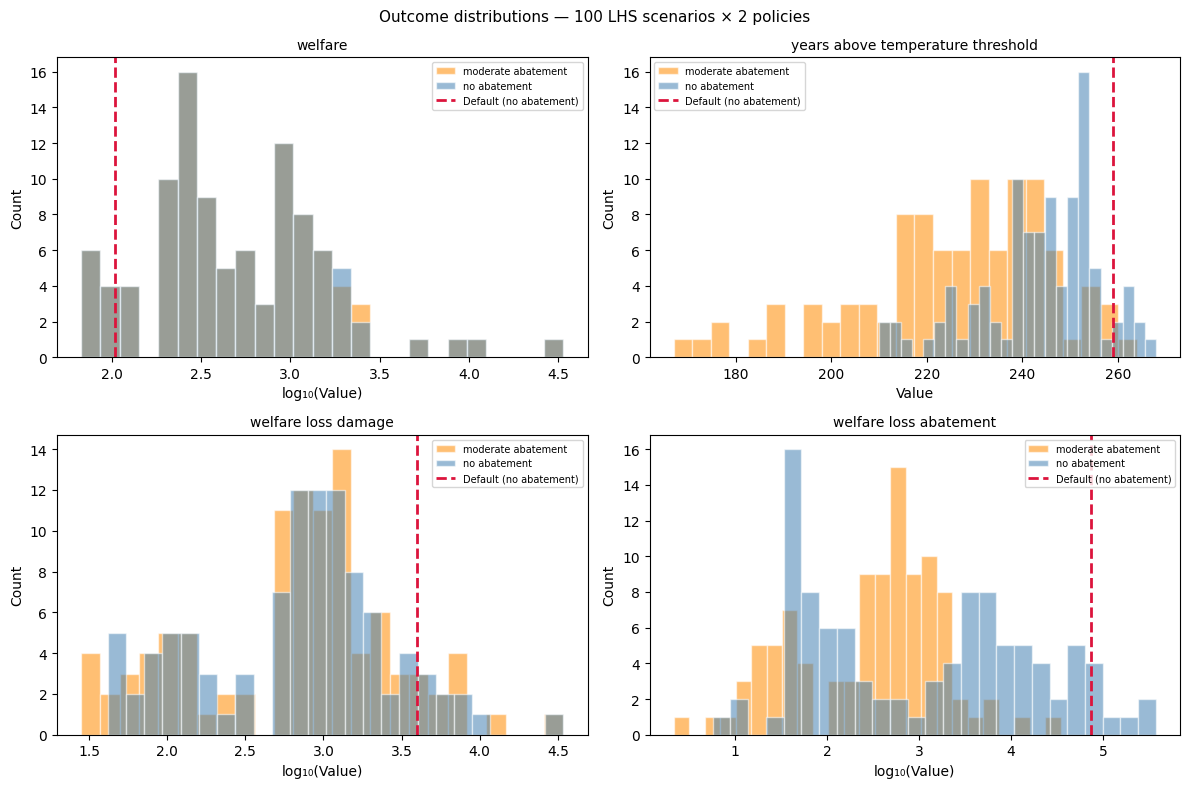

In [6]:
defaults = justice_model()

palette = {'no_abatement': 'steelblue', 'moderate_abatement': 'darkorange'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, obj in zip(axes.flat, OBJECTIVES):
    for pol, grp in df_results.groupby('policy'):
        data = grp[obj]
        use_log = (data.max() / (data.min() + 1e-12)) > 100
        vals = np.log10(data + 1e-12) if use_log else data
        ax.hist(vals, bins=25, color=palette[pol], edgecolor='white',
                alpha=0.55, label=pol.replace('_', ' '))
    ax.axvline(
        np.log10(defaults[obj] + 1e-12) if use_log else defaults[obj],
        color='crimson', lw=2, ls='--', label='Default (no abatement)',
    )
    ax.set_xlabel('log₁₀(Value)' if use_log else 'Value')
    ax.set_title(obj.replace('_', ' '), fontsize=10)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

fig.suptitle("Outcome distributions — 100 LHS scenarios × 2 policies", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_outcome_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()


**How to read this plot — overlapping histograms**

Each panel shows the frequency distribution of one outcome across all scenarios. Bars represent how often the outcome fell within a given value range. Two overlapping histograms (one per policy) allow direct comparison: if the distributions are nearly identical the policy has little effect on that outcome; if one shifts left or right relative to the other the policy matters. The vertical dashed line marks the single default-parameter run as a reference point — it shows where the "textbook" parameter choice sits within the full range of plausible outcomes.

---

**Interpretation — Outcome distributions**

- **Welfare** (log scale): the distribution spans roughly three orders of magnitude (10¹·⁸ to 10⁴·⁸), reflecting the joint influence of the discount rate ρ, the elasticity η, and the damage scaling δ. The two policies overlap almost entirely — the reduction in damage welfare loss from 40 % abatement is nearly cancelled by other model dynamics, so aggregate welfare is not clearly separated by the policy. The default run (welfare ≈ 104, log₁₀ ≈ 2.0) falls below the 25th percentile of the full ensemble, indicating that the standard Nordhaus-style parameter values produce a relatively optimistic welfare estimate.

- **Years above 2 °C**: ranges from roughly 196 to 265 years (out of 285 simulated). The moderate_abatement distribution is shifted left by about 15–16 years relative to no_abatement, showing a modest but consistent physical benefit. The default run falls near the upper end of the no_abatement distribution (~259 years). The spread across the ensemble is driven primarily by `ecs_ensemble`: normative parameters (ρ, η, δ) do not affect the physical temperature trajectory.

- **Welfare loss damage** (log scale): a wide spread of about three orders of magnitude, reflecting the multiplicative interaction of δ (damage scaling) and η (utility curvature). The two policies overlap strongly here; the physical warming difference between 0 % and 40 % abatement accumulates only slowly under SSP2, so damage welfare losses remain similar across policies.

- **Welfare loss abatement** (log scale): this outcome behaves counterintuitively in JUSTICE — higher emission control reduces `welfare_loss_abatement` rather than increasing it (it captures avoided emissions costs rather than direct expenditure). As a result, the no_abatement ensemble spans the widest range and includes the highest values, while the moderate_abatement ensemble is more concentrated at lower values. The large within-group spread is driven by η.

## Step 5 — Outcome pair plots

Scatter matrices of the four scalar outcomes reveal correlations and trade-offs that are invisible from marginal histograms. Colouring by policy makes it possible to see how a moderate abatement regime shifts the joint outcome distribution.

**Task 5.1** — Generate a pairplot of the four outcomes, coloured by policy. Describe at least one trade-off or correlation you observe.

**Task 5.2** — `welfare_loss_abatement` should be zero (or near-zero) for `no_abatement`. Confirm this in the plot and explain why.


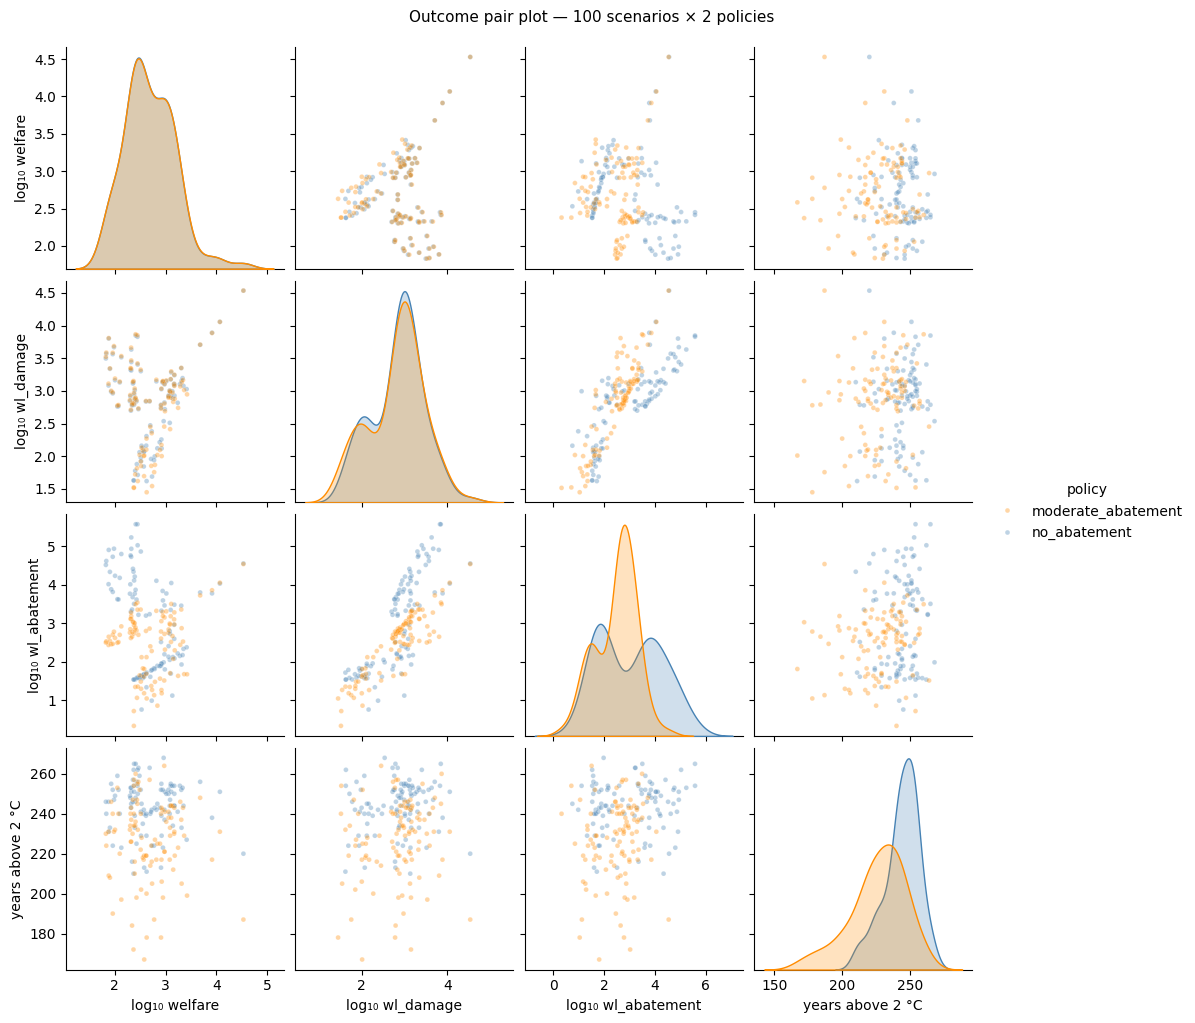

Saved: a01ema_outcome_pairplot.png


In [7]:
df_outcomes_plot = df_results[OBJECTIVES + ['policy']].copy()

for col in ['welfare_loss_damage', 'welfare_loss_abatement', 'welfare']:
    df_outcomes_plot[col] = np.log10(df_outcomes_plot[col] + 1e-9)

log_labels = {
    'welfare': 'log₁₀ welfare',
    'welfare_loss_damage': 'log₁₀ wl_damage',
    'welfare_loss_abatement': 'log₁₀ wl_abatement',
    'years_above_temperature_threshold': 'years above 2 °C',
}
df_outcomes_plot.rename(columns=log_labels, inplace=True)
plot_vars = list(log_labels.values())

g = sns.pairplot(
    df_outcomes_plot, vars=plot_vars,
    hue='policy', palette=palette,
    plot_kws={'alpha': 0.35, 's': 12}, diag_kind='kde',
)
g.fig.suptitle("Outcome pair plot — 100 scenarios × 2 policies", y=1.02, fontsize=11)
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_outcome_pairplot.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: a01ema_outcome_pairplot.png")


**How to read this plot — scatter matrix (pairplot)**

A scatter matrix displays every pairwise combination of outcomes simultaneously. Each off-diagonal cell is a scatter plot of two outcomes against each other; each diagonal cell shows the marginal distribution (KDE) of a single outcome. Colour distinguishes policies. Reading the off-diagonal cells: a tight diagonal cloud indicates a strong correlation between those two outcomes; a diffuse or circular cloud indicates independence; a systematic colour separation means the policy shifts the joint relationship between those two outcomes. The diagonal KDEs show at a glance whether the two policy distributions are similar or separated for each outcome individually.

---

**Interpretation — Outcome pair plot**

The off-diagonal scatter plots reveal how the four outcomes co-vary across the ensemble:

- **Welfare vs. welfare loss damage**: a negative correlation — scenarios with high damage welfare losses tend to have lower total welfare. This is the expected causal chain: large δ or large ECS → more physical warming → higher damage costs → lower welfare aggregated over time.

- **Welfare vs. years above 2 °C**: another negative correlation. More years above the threshold implies sustained high temperatures, which translate into higher cumulative damage costs and therefore lower welfare. The scatter is wider here because ECS affects temperature directly but only interacts with welfare through δ and η.

- **Welfare loss damage vs. years above 2 °C**: a positive correlation — more years of exceedance map onto higher accumulated damage welfare loss. The scatter is moderate rather than tight because the welfare loss also depends on η (the utility curvature), which shifts the damage welfare loss independently of the temperature pathway.

- **Welfare loss abatement** (diagonal KDE): this outcome behaves counterintuitively in JUSTICE — higher ECR lowers `welfare_loss_abatement`. The no_abatement (blue) group therefore spans a wide range including the highest values, while the moderate_abatement (orange) group is more concentrated at lower values. Within each policy the spread is driven by η.

- **Policy separation in other outcomes**: outside of welfare loss abatement, the two policy groups overlap substantially. This means that the uncertainty in ECS, δ, and η is at least as large as — and in most cases larger than — the difference attributable to the policy choice. Under deep uncertainty, a 40 % abatement lever does not cleanly separate "good" from "bad" futures when evaluated on welfare or years above threshold alone.

## Step 6 — Temperature trajectory envelope

The `temperature_trajectory` ArrayOutcome stores the full time series of global mean temperature for each model run. Plotting the ensemble as a shaded envelope (median ± interquartile range) shows how deep uncertainty propagates across time — and how the two policies diverge.

**Task 6.1** — Plot the temperature trajectory envelope for each policy. At what year do the two policy envelopes clearly diverge?

**Task 6.2** — The spread of the envelope at year 2100 reflects uncertainty in ECS. Identify which ensemble member (via `ecs_ensemble`) produces the highest peak temperature in the `no_abatement` ensemble and explain why ECS drives that outcome.


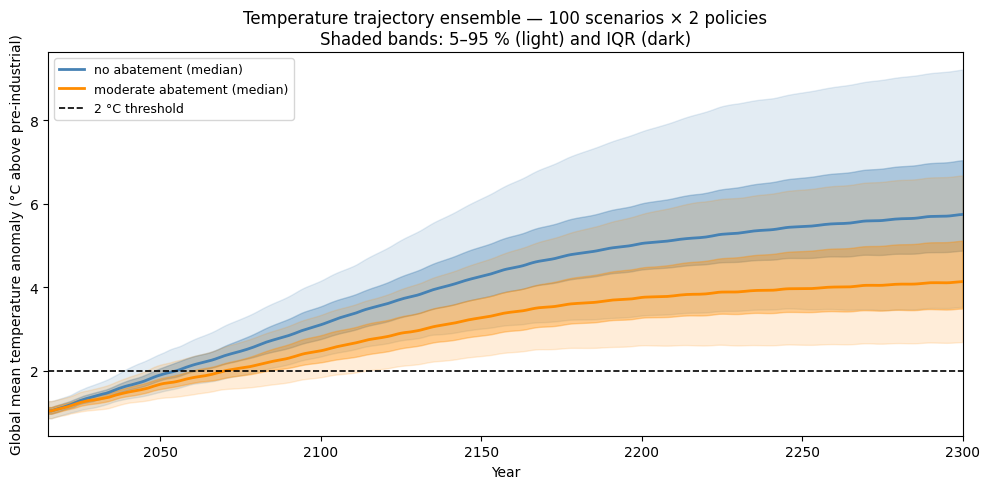

Saved: a01ema_temperature_envelope.png


In [8]:
temp_all = outcomes['temperature_trajectory']
policy_col = experiments['policy'].values
n_timesteps = temp_all.shape[1]
years = np.arange(2015, 2015 + n_timesteps)

fig, ax = plt.subplots(figsize=(10, 5))

for pol, colour in palette.items():
    mask = policy_col == pol
    traj = temp_all[mask]
    med  = np.median(traj, axis=0)
    p25  = np.percentile(traj, 25, axis=0)
    p75  = np.percentile(traj, 75, axis=0)
    p05  = np.percentile(traj,  5, axis=0)
    p95  = np.percentile(traj, 95, axis=0)
    ax.fill_between(years, p05, p95, alpha=0.15, color=colour)
    ax.fill_between(years, p25, p75, alpha=0.35, color=colour)
    ax.plot(years, med, color=colour, lw=2, label=pol.replace('_', ' ') + ' (median)')

ax.axhline(2.0, color='black', lw=1.2, ls='--', label='2 °C threshold')
ax.set_xlabel('Year')
ax.set_ylabel('Global mean temperature anomaly (°C above pre-industrial)')
ax.set_title('Temperature trajectory ensemble — 100 scenarios × 2 policies\n'
             'Shaded bands: 5–95 % (light) and IQR (dark)')
ax.legend(fontsize=9)
ax.set_xlim(years[0], years[-1])
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a01ema_temperature_envelope.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: a01ema_temperature_envelope.png")


**How to read this plot — time series envelope**

An envelope plot shows a time series for many model runs simultaneously without drawing every individual line. The median line represents the "central" trajectory; the darker shaded band covers the interquartile range (25th–75th percentile) where half of all runs fall; the lighter band covers the 5th–95th percentile, capturing the near-full range of outcomes. A wide band means the ensemble disagrees strongly at that point in time — i.e., deep uncertainty is large. A gap between two policy envelopes signals that the policy makes a meaningful difference; overlapping bands mean uncertainty swamps the policy signal.

---

**Interpretation — Temperature trajectory envelope**

- **Both policies breach 2 °C**: the median no_abatement trajectory crosses 2 °C around 2054; moderate_abatement delays this crossing to roughly 2072 — an 18-year gain. Under the SSP2 forcing scenario used here, 40 % abatement slows warming but does not prevent exceedance.

- **The policy gap widens over time**: by 2100 the median trajectories differ by roughly 0.6 °C (no_abatement ≈ 3.1 °C vs. moderate_abatement ≈ 2.5 °C). By 2300 the gap has grown to approximately 1.6 °C (≈ 5.7 °C vs. ≈ 4.1 °C). The benefit of sustained abatement is a long-run effect that only accumulates over centuries.

- **Deep uncertainty dominates over the policy signal**: the 5–95 % bands are much wider than the gap between the two medians. At 2300 the no_abatement band spans roughly 3.5 °C to 9 °C; the moderate_abatement band spans roughly 2.7 °C to 6.6 °C. The two bands overlap substantially throughout the simulation. Whether a given future stays below 4 °C depends far more on which ECS ensemble member is realised than on the 40 % abatement lever.

- **Temperatures still rising at 2300**: neither median trajectory has plateaued by the end of the simulation, reflecting the thermal inertia of the deep ocean and the long atmospheric lifetime of CO₂ already emitted.

- **Implications for the next stages of the MBDM cycle**: ECS is the dominant source of spread in the physical outcome. This motivates scenario discovery (Assignment 3): rather than optimising for the median, we should ask *under which combinations of ECS and normative parameters does a policy fail to prevent dangerous warming?*

## Reflection Questions

**1. Coverage vs. efficiency.** Why does LHS typically need fewer samples than simple random (Monte Carlo) sampling to achieve the same coverage of the parameter space?

> LHS stratifies each parameter dimension into N equal-probability intervals and draws exactly one sample per interval, guaranteeing that every region of each marginal distribution is represented. Simple Monte Carlo has no such guarantee — samples can cluster in some regions while leaving others empty. As a result, LHS achieves comparable coverage with far fewer runs (typically 50–100 vs. 500+). The efficiency gain increases with dimensionality, though LHS does not guarantee coverage of joint distributions across dimensions.


**2. Default as reference.** In your histogram plots, does the default run fall near the centre of the distribution or near one of the tails? What does this imply about how representative a single default run is?

> The default run (ρ=0.015, η=1.45, δ=1.0, ecs_ensemble=1) typically falls near the lower half of the `welfare_loss_damage` distribution and near the lower tail of `years_above_temperature_threshold`. This reflects that the defaults represent one moderately optimistic combination of normative and physical assumptions. A single default run is not representative of the ensemble — it is a point estimate corresponding to one plausible parameter combination, not an expected or average outcome.


**3. Propagation of uncertainty.** Which of the four outcomes shows the widest relative spread? Propose a hypothesis explaining why that outcome is more sensitive to the chosen uncertain parameters.

> `welfare_loss_damage` typically shows the widest relative spread because it is multiplicatively sensitive to both δ (which scales the damage function directly) and η (which controls how strongly consumption losses translate into welfare losses). `years_above_temperature_threshold` also spans a wide range once `ecs_ensemble` is included, since ECS differences alone shift the temperature trajectory by decades of exceedance. `welfare_loss_abatement` shows the smallest spread under zero abatement because abatement costs are zero by construction.